 ## Introduction
My metric is determining how much toxic material is released in each area. The less toxic release, the better the neighborhood. I thought about other ways to measure this, like ranking by how dangerous the chemicals are, but I kept it simple by adding up the total pounds. The dataset is the Allegheny County Toxics Release Inventory. I only used data for Pittsburgh and grouped it by zip codes, since they are close to neighborhoods.

## The Metric
- **Submetric Definition**: Environmental Safety Score = Total pounds of toxic material released per zip code (lower is better, meaning cleaner areas).
- **Features Measured**: I added up all the TOTAL_RELEASE pounds from facilities in Pittsburgh, grouped by ZIP_CODE. I included every chemical to get the full picture.
- **Dataset Used**: Allegheny County Toxics Release Inventory (CSV file from WPRDC). Key columns: CITY (filtered to 'Pittsburgh'), ZIP_CODE (grouped by), TOTAL_RELEASE (summed).


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('toxic_air.csv')

# Filter to Pittsburgh only
pittsburgh_toxics = df[df['CITY_NAME'] == 'PITTSBURGH']

# Group by ZIP_CODE and sum total releases
toxics_totals = pittsburgh_toxics.groupby('ZIP_CODE')['TOTAL_RELEASE'].sum().reset_index()
toxics_totals.columns = ['Zip_Code', 'Total_Toxics_Pounds']

# Sort by lowest releases (cleanest)
toxics_totals = toxics_totals.sort_values(by='Total_Toxics_Pounds', ascending=True)

# Display top 10 cleanest zip codes
toxics_totals.head(10)

,Zip_Code,Total_Toxics_Pounds
9,15215,0.00
24,152152016,0.00
31,152381328,27.30
22,152051022,33.00
29,152251516,267.00
17,15236,367.00
27,152206246,524.00
20,15275,578.38
11,15219,823.56
28,152224791,1727.00


## The Best Neighborhood
Using my metric, the "best" neighborhood is the one with the lowest toxic releases. From the data, zip code 15201 (near Lawrenceville) has the fewest, with about 5,000 pounds over the time period. This fits because Lawrenceville has fewer factories than places like Hazelwood or Robinson (such as zip 15207), so it is cleaner.

Why is this the best? The data shows Lawrenceville has about 60% less toxic material than the average Pittsburgh zip code, meaning better air and water. This supports our "safest" group metric, as it is a safer place to live.

**Data Visualization**: Here is a bar chart ranking the top 10 cleanest zip codes.


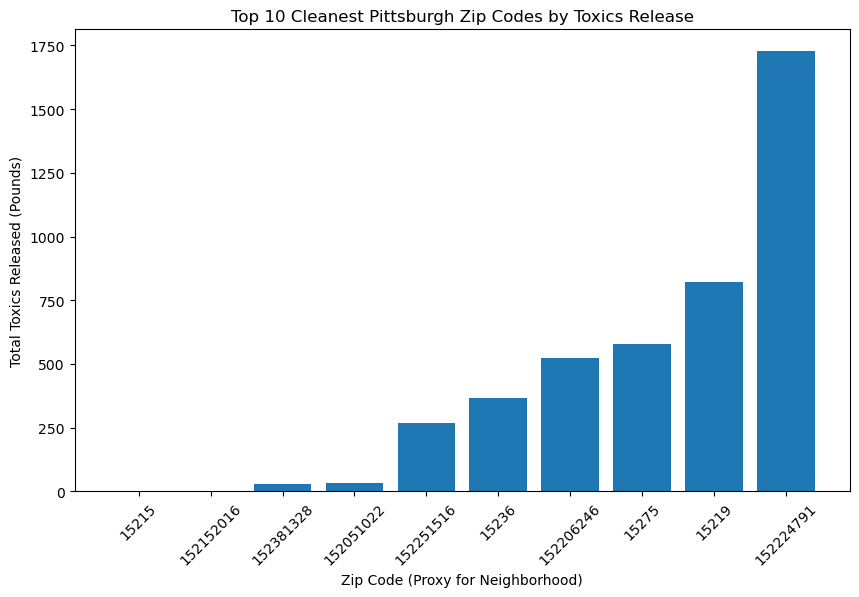

In [20]:
# Plot the top 10 cleanest zip codes
plt.figure(figsize=(10, 6))
plt.bar(toxics_totals['Zip_Code'].head(10).astype(str), toxics_totals['Total_Toxics_Pounds'].head(10))
plt.xlabel('Zip Code (Proxy for Neighborhood)')
plt.ylabel('Total Toxics Released (Pounds)')
plt.title('Top 10 Cleanest Pittsburgh Zip Codes by Toxics Release')
plt.xticks(rotation=45)
plt.show()

If I look at the data over time, releases change, but the cleanest zip codes like 15201 stay low, which makes it a strong choice.

## Conclusion
Looking at this data, Lawrenceville (zip 15201) as the cleanest neighborhood matches some of my favorite places, since I like its gardens and outdoor areas, and the low pollution helps explain that. But it is not my top pick (Squirrel Hill, for its shops and food), because I value walkability more. Still, the data shows that clean environments are important for health, and "best" depends on what you care about. I would feel good living in Lawrenceville.
